# Machine Learning Lab - Assignment 05
# Exploratory Data Analysis 

**Name:** Abu Bakar Sadiq
### Program : AI "B" 
**Assignment:** FIFA 21  Dataset EDA | 
**Date:** Oct 7 2026



## Setup

In [16]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13

# Find the two CSV files automatically (works locally and on Kaggle)
def find_file(patterns):
    folders = [".", "/kaggle/working", "/kaggle/input"]
    for folder in folders:
        for pattern in patterns:
            hits = glob.glob(os.path.join(folder, "**", pattern), recursive=True)
            hits = [h for h in hits if ".ipynb_checkpoints" not in h]
            if hits:
                return hits[0]
    raise FileNotFoundError(f"Could not find any of: {patterns}")

RAW_PATH   = find_file(["*fifa21*raw*data*.csv"])
CLEAN_PATH = find_file(["fifa21_cleaned_data.csv"])
print("Raw file  :", RAW_PATH)
print("Clean file:", CLEAN_PATH)

raw   = pd.read_csv(RAW_PATH, low_memory=False)
clean = pd.read_csv(CLEAN_PATH, low_memory=False)

Raw file  : .\fifa21 raw data v2.csv
Clean file: .\fifa21_cleaned_data.csv


In [17]:
# Rule 5: check the exact column names yourself
print("RAW   :", raw.columns.tolist())
print()
print("CLEAN :", clean.columns.tolist())

# The raw file uses '↓OVA' and the cleaned file uses 'OVA'
RAW_OVA = [c for c in raw.columns if "OVA" in c][0]
print("\nRaw OVA column name:", repr(RAW_OVA))

RAW   : ['ID', 'Name', 'LongName', 'photoUrl', 'playerUrl', 'Nationality', 'Age', '↓OVA', 'POT', 'Club', 'Contract', 'Positions', 'Height', 'Weight', 'Preferred Foot', 'BOV', 'Best Position', 'Joined', 'Loan Date End', 'Value', 'Wage', 'Release Clause', 'Attacking', 'Crossing', 'Finishing', 'Heading Accuracy', 'Short Passing', 'Volleys', 'Skill', 'Dribbling', 'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control', 'Movement', 'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance', 'Power', 'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots', 'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure', 'Defending', 'Marking', 'Standing Tackle', 'Sliding Tackle', 'Goalkeeping', 'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes', 'Total Stats', 'Base Stats', 'W/F', 'SM', 'A/W', 'D/W', 'IR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Hits']

CLEAN : ['ID', 'Name', 'LongName', 'photoUrl', 'playerUrl', 'Nationality'

## Part A: Know the files (uncleaned and cleaned)

### A1. Shape and data types of both files

In [18]:
for name, d in [("RAW", raw), ("CLEAN", clean)]:
    num = d.select_dtypes(include="number").columns.tolist()
    oth = d.select_dtypes(exclude="number").columns.tolist()
    print(f"{name}: {d.shape[0]} rows, {d.shape[1]} columns")
    print(f"  numeric columns: {len(num)}   text/other columns: {len(oth)}")
    print(f"  text/other columns: {oth}\n")

RAW: 18979 rows, 77 columns
  numeric columns: 54   text/other columns: 23
  text/other columns: ['Name', 'LongName', 'photoUrl', 'playerUrl', 'Nationality', 'Club', 'Contract', 'Positions', 'Height', 'Weight', 'Preferred Foot', 'Best Position', 'Joined', 'Loan Date End', 'Value', 'Wage', 'Release Clause', 'W/F', 'SM', 'A/W', 'D/W', 'IR', 'Hits']

CLEAN: 18979 rows, 79 columns
  numeric columns: 64   text/other columns: 15
  text/other columns: ['Name', 'LongName', 'photoUrl', 'playerUrl', 'Nationality', 'Club', 'Contract', 'Positions', 'Preferred Foot', 'Best Position', 'Joined', 'Loan Date End', 'A/W', 'D/W', 'Wage_Outlier']



In [19]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 77 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ID                18979 non-null  int64
 1   Name              18979 non-null  str  
 2   LongName          18979 non-null  str  
 3   photoUrl          18979 non-null  str  
 4   playerUrl         18979 non-null  str  
 5   Nationality       18979 non-null  str  
 6   Age               18979 non-null  int64
 7   ↓OVA              18979 non-null  int64
 8   POT               18979 non-null  int64
 9   Club              18979 non-null  str  
 10  Contract          18979 non-null  str  
 11  Positions         18979 non-null  str  
 12  Height            18979 non-null  str  
 13  Weight            18979 non-null  str  
 14  Preferred Foot    18979 non-null  str  
 15  BOV               18979 non-null  int64
 16  Best Position     18979 non-null  str  
 17  Joined            18979 non-null  str  
 1

In [20]:
clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 79 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                18979 non-null  int64  
 1   Name              18979 non-null  str    
 2   LongName          18979 non-null  str    
 3   photoUrl          18979 non-null  str    
 4   playerUrl         18979 non-null  str    
 5   Nationality       18979 non-null  str    
 6   Age               18979 non-null  int64  
 7   ↓OVA              18979 non-null  int64  
 8   POT               18979 non-null  int64  
 9   Club              18979 non-null  str    
 10  Contract          18979 non-null  str    
 11  Positions         18979 non-null  str    
 12  Height            18979 non-null  float64
 13  Weight            18979 non-null  float64
 14  Preferred Foot    18979 non-null  str    
 15  BOV               18979 non-null  int64  
 16  Best Position     18979 non-null  str    
 17  Join

**Observation (A1):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Which columns are numbers and which are text in each file? Which important columns changed from text to number?

### A2. Missing values per column (bar charts)

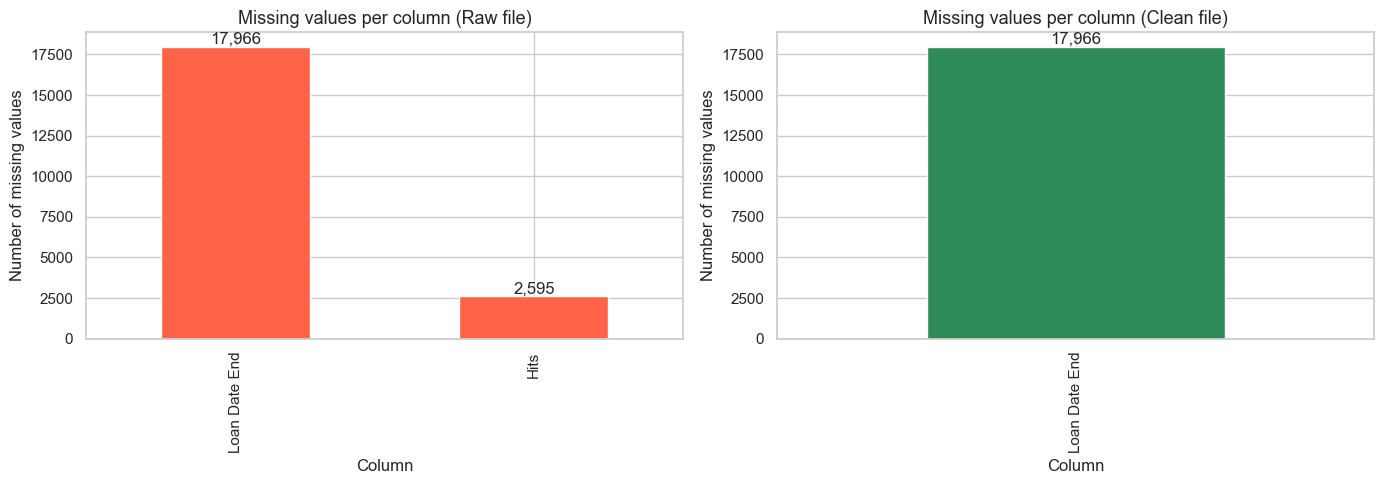

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, d, colr) in zip(axes, [("Raw", raw, "tomato"), ("Clean", clean, "seagreen")]):
    miss = d.isnull().sum()
    miss = miss[miss > 0]
    miss.plot.bar(ax=ax, color=colr)
    ax.set_title(f"Missing values per column ({name} file)")
    ax.set_xlabel("Column")
    ax.set_ylabel("Number of missing values")
    for i, v in enumerate(miss.values):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Observation (A2):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Which file has more missing values, and in which columns?

### A3. Five values of Value, Wage, Height, Weight and Hits (raw vs cleaned)

In [22]:
cols5 = ["Value", "Wage", "Height", "Weight", "Hits"]
print("RAW file")
display(raw[cols5].head(5))
print("CLEANED file")
display(clean[cols5].head(5))

RAW file


,Value,Wage,Height,Weight,Hits
0,€103.5M,€560K,170cm,72kg,771
1,€63M,€220K,187cm,83kg,562
2,€120M,€125K,188cm,87kg,150
3,€129M,€370K,181cm,70kg,207
4,€132M,€270K,175cm,68kg,595


CLEANED file


,Value,Wage,Height,Weight,Hits
0,103500000.0,560000.0,170.0,72.0,771.0
1,63000000.0,220000.0,187.0,83.0,562.0
2,120000000.0,125000.0,188.0,87.0,150.0
3,129000000.0,370000.0,181.0,70.0,207.0
4,132000000.0,270000.0,175.0,68.0,595.0


**What is wrong in the raw file (fill in):**

| Column | What is wrong |
|---|---|
| Value | |
| Wage | |
| Height | |
| Weight | |
| Hits | |

### A4. Histogram of Value: raw vs cleaned

In [23]:
# Raw file: Value is text, so a histogram cannot be drawn
try:
    raw["Value"].plot.hist(bins=30)
    plt.title("Value (raw file)")
    plt.show()
except Exception as e:
    print("Raw histogram failed ->", type(e).__name__, ":", e)

Raw histogram failed -> TypeError : no numeric data to plot


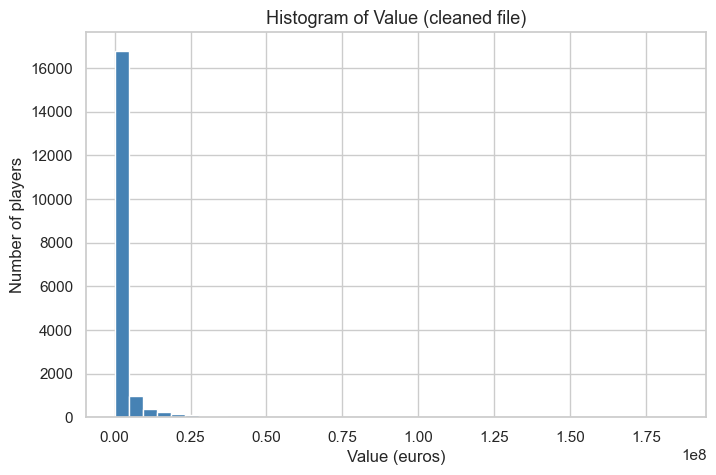

In [24]:
# Cleaned file: Value is numeric, so the histogram works
plt.hist(clean["Value"], bins=40, color="steelblue", edgecolor="white")
plt.title("Histogram of Value (cleaned file)")
plt.xlabel("Value (euros)")
plt.ylabel("Number of players")
plt.show()

**Observation (A4):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Explain in one sentence why the raw histogram fails or is meaningless.

### A5. Heatmap of missing values (raw file)

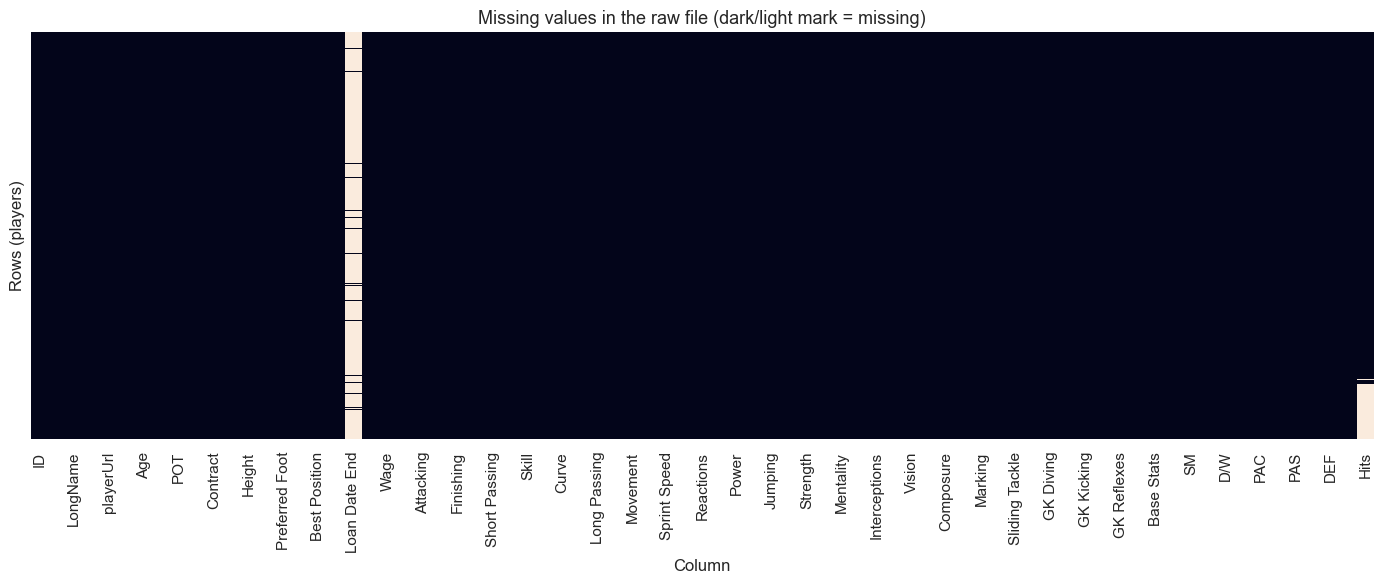

In [25]:
plt.figure(figsize=(14, 6))
sns.heatmap(raw.isnull(), cbar=False, yticklabels=False)
plt.title("Missing values in the raw file (dark/light mark = missing)")
plt.xlabel("Column")
plt.ylabel("Rows (players)")
plt.tight_layout()
plt.show()

**Observation (A5):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Do the missing values sit in a few columns or are they spread everywhere?

## Part B: One column at a time (cleaned file)

### B1. Value: histogram with mean and median

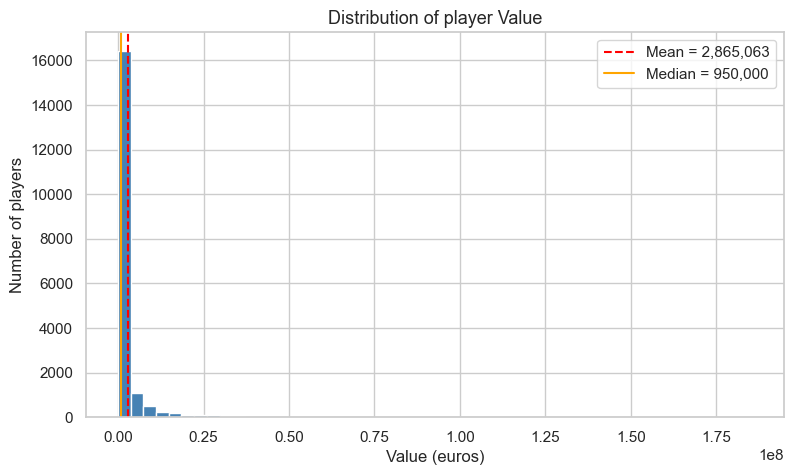

In [26]:
plt.figure(figsize=(9, 5))
plt.hist(clean["Value"], bins=50, color="steelblue", edgecolor="white")
plt.axvline(clean["Value"].mean(),   color="red",    linestyle="--", label=f"Mean = {clean['Value'].mean():,.0f}")
plt.axvline(clean["Value"].median(), color="orange", linestyle="-",  label=f"Median = {clean['Value'].median():,.0f}")
plt.title("Distribution of player Value")
plt.xlabel("Value (euros)")
plt.ylabel("Number of players")
plt.legend()
plt.show()

**Observation (B1):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Is the shape balanced or does it have a long tail? On which side?

### B2. Value: boxplot

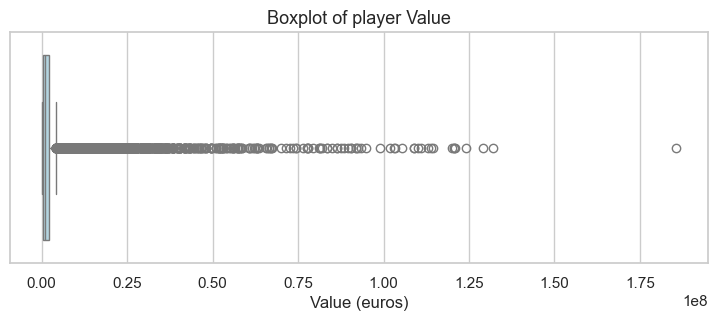

Upper whisker limit: 4,287,500
Players shown as dots above the box: 2297


In [27]:
plt.figure(figsize=(9, 3))
sns.boxplot(x=clean["Value"], color="lightblue")
plt.title("Boxplot of player Value")
plt.xlabel("Value (euros)")
plt.show()

# Count the dots above the box (above the upper whisker)
q1, q3 = clean["Value"].quantile([0.25, 0.75])
upper_whisker = q3 + 1.5 * (q3 - q1)
print("Upper whisker limit:", f"{upper_whisker:,.0f}")
print("Players shown as dots above the box:", (clean["Value"] > upper_whisker).sum())

**Observation (B2):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: How many dots appear far above the box? What do they represent in football terms?

### B3. Age, OVA and POT: three histograms side by side

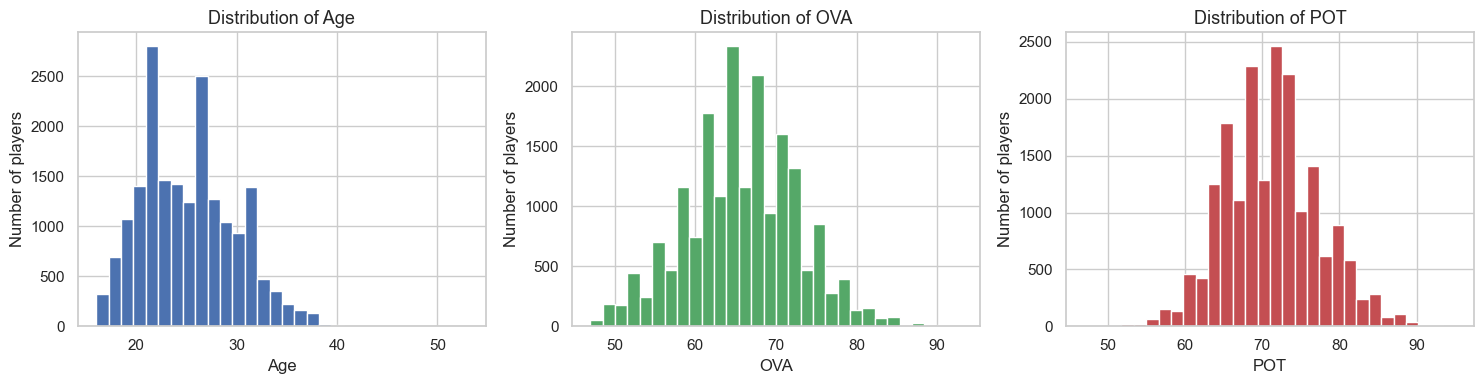

Most common age: 23


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, colr in zip(axes, ["Age", "OVA", "POT"], ["#4c72b0", "#55a868", "#c44e52"]):
    hist_col = "↓OVA" if col == "OVA" else col
    ax.hist(clean[hist_col], bins=30, color=colr, edgecolor="white")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of players")
plt.tight_layout()
plt.show()

print("Most common age:", clean["Age"].mode()[0])

**Observation (B3):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Which one is closest to a bell shape? What is the most common age?

### B4. Wage and Hits: one histogram each

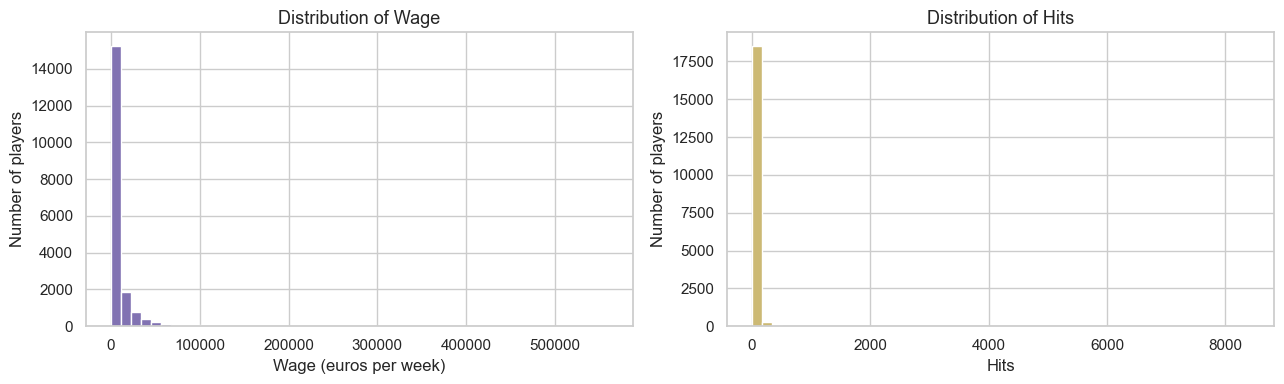

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(clean["Wage"], bins=50, color="#8172b2", edgecolor="white")
axes[0].set_title("Distribution of Wage")
axes[0].set_xlabel("Wage (euros per week)")
axes[0].set_ylabel("Number of players")

axes[1].hist(clean["Hits"], bins=50, color="#ccb974", edgecolor="white")
axes[1].set_title("Distribution of Hits")
axes[1].set_xlabel("Hits")
axes[1].set_ylabel("Number of players")
plt.tight_layout()
plt.show()

**Observation (B4):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Compare the shape of Wage and Hits with the shape of Value.

### B5. Height and Weight: one histogram each

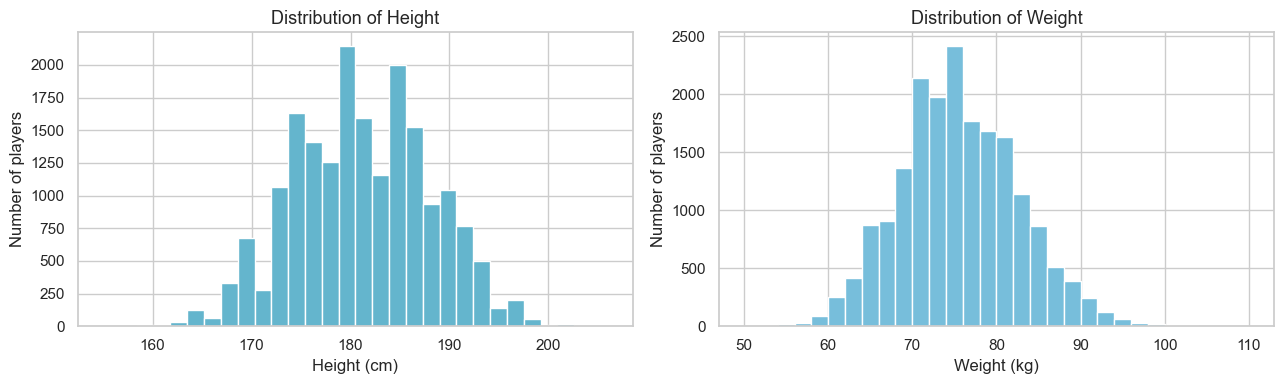

Typical (median) height: 181.0 cm
Typical (median) weight: 75.0 kg


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(clean["Height"], bins=30, color="#64b5cd", edgecolor="white")
axes[0].set_title("Distribution of Height")
axes[0].set_xlabel("Height (cm)")
axes[0].set_ylabel("Number of players")

axes[1].hist(clean["Weight"], bins=30, color="#77bedb", edgecolor="white")
axes[1].set_title("Distribution of Weight")
axes[1].set_xlabel("Weight (kg)")
axes[1].set_ylabel("Number of players")
plt.tight_layout()
plt.show()

print("Typical (median) height:", clean["Height"].median(), "cm")
print("Typical (median) weight:", clean["Weight"].median(), "kg")

**Observation (B5):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: What is the typical height and weight of a player?

### B6. Value on a log scale

Players with Value = 0 left out of this plot: 248


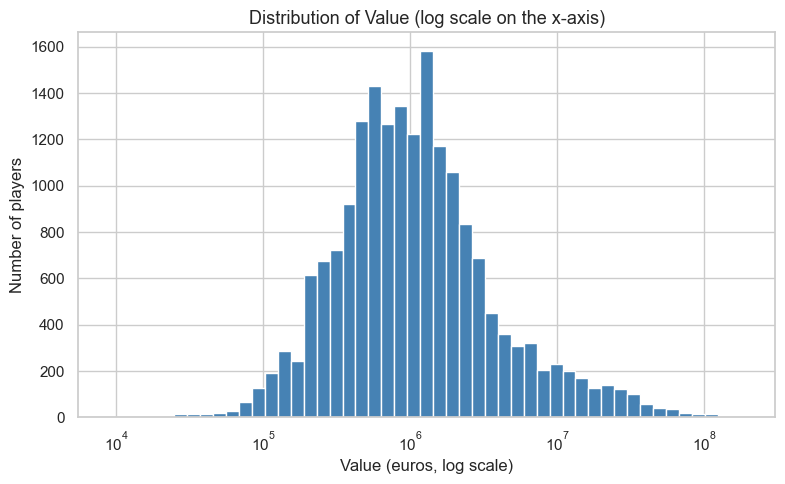

In [32]:
# Filter only for this plot: log of 0 is undefined, so zero Values are left out of the drawing
v = clean.loc[clean["Value"] > 0, "Value"]
print("Players with Value = 0 left out of this plot:", (clean["Value"] == 0).sum())

bins = np.logspace(np.log10(v.min()), np.log10(v.max()), 50)
plt.figure(figsize=(9, 5))
plt.hist(v, bins=bins, color="steelblue", edgecolor="white")
plt.xscale("log")
plt.title("Distribution of Value (log scale on the x-axis)")
plt.xlabel("Value (euros, log scale)")
plt.ylabel("Number of players")
plt.show()

**Observation (B6):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Compare it with B1. What is different about the shape now?

### B7. Cumulative curve of Value

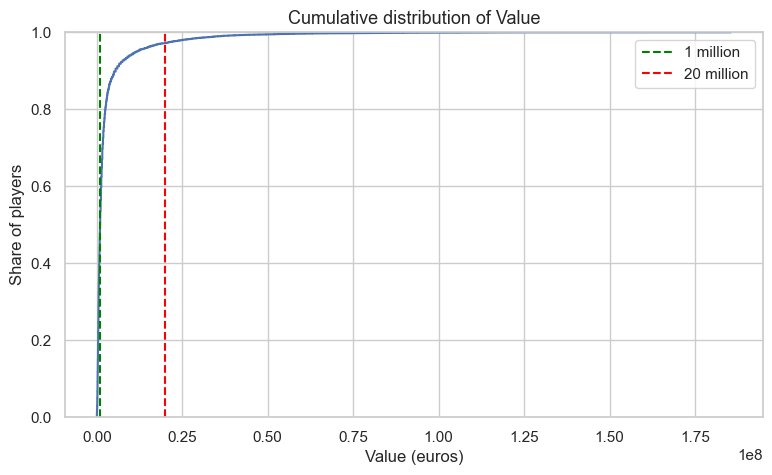

Share of players worth less than 1 million : 51.0%
Share of players worth more than 20 million: 2.8%


In [33]:
plt.figure(figsize=(9, 5))
sns.ecdfplot(data=clean, x="Value")
plt.axvline(1_000_000,  color="green", linestyle="--", label="1 million")
plt.axvline(20_000_000, color="red",   linestyle="--", label="20 million")
plt.title("Cumulative distribution of Value")
plt.xlabel("Value (euros)")
plt.ylabel("Share of players")
plt.legend()
plt.show()

print(f"Share of players worth less than 1 million : {(clean['Value'] < 1_000_000).mean():.1%}")
print(f"Share of players worth more than 20 million: {(clean['Value'] > 20_000_000).mean():.1%}")

**Observation (B7):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: What share of players are worth less than 1 million, and what share more than 20 million?

### B8. Number of players per Best Position

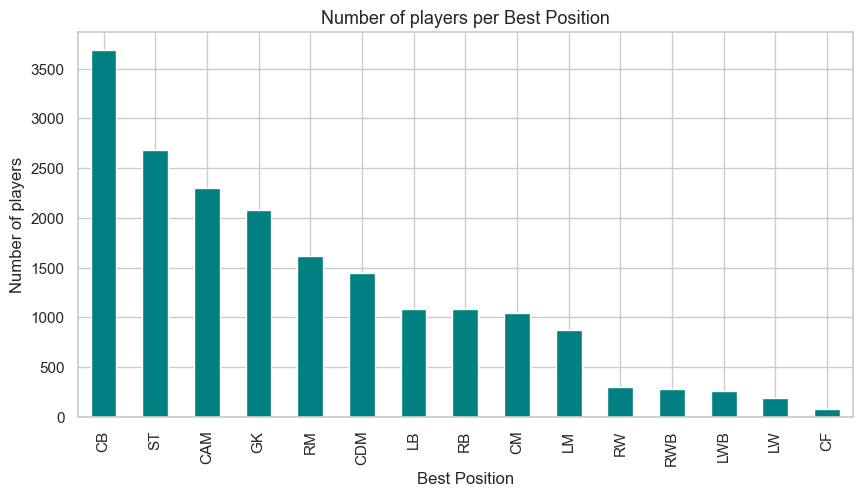

Most common: CB 3686
Rarest     : CF 78


In [34]:
pos_counts = clean["Best Position"].value_counts()
plt.figure(figsize=(10, 5))
pos_counts.plot.bar(color="teal")
plt.title("Number of players per Best Position")
plt.xlabel("Best Position")
plt.ylabel("Number of players")
plt.show()

print("Most common:", pos_counts.idxmax(), pos_counts.max())
print("Rarest     :", pos_counts.idxmin(), pos_counts.min())

**Observation (B8):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Which position is most common and which is rarest?

### B9 (Extra). PAC, SHO, PAS, DRI, DEF, PHY in a 2 by 3 grid

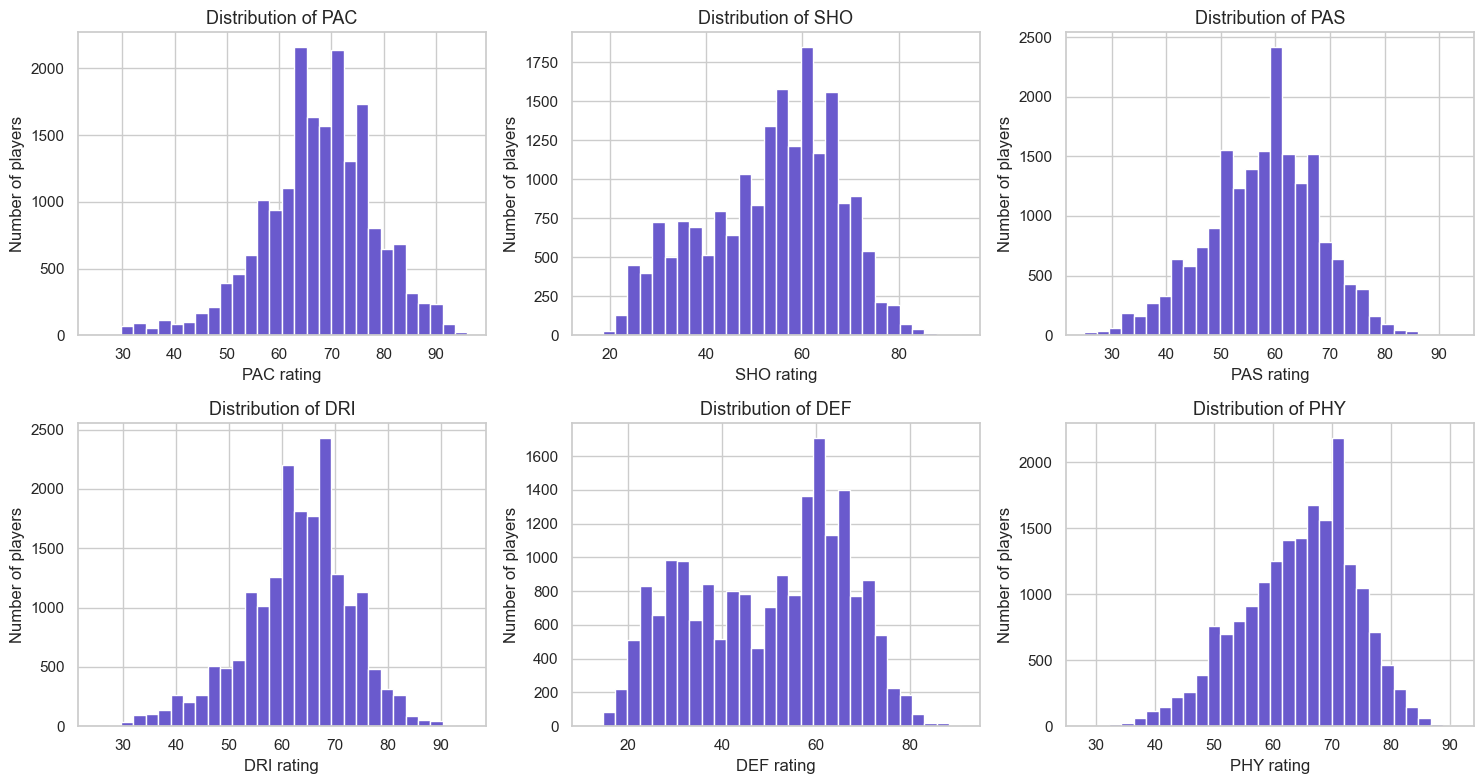

In [35]:
six = ["PAC", "SHO", "PAS", "DRI", "DEF", "PHY"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), six):
    ax.hist(clean[col], bins=30, color="slateblue", edgecolor="white")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(f"{col} rating")
    ax.set_ylabel("Number of players")
plt.tight_layout()
plt.show()

**Observation (B9 (Extra)):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Which one has two peaks, and what might cause that?

## Part C: Two columns together (cleaned file)

### C1. OVA against Value

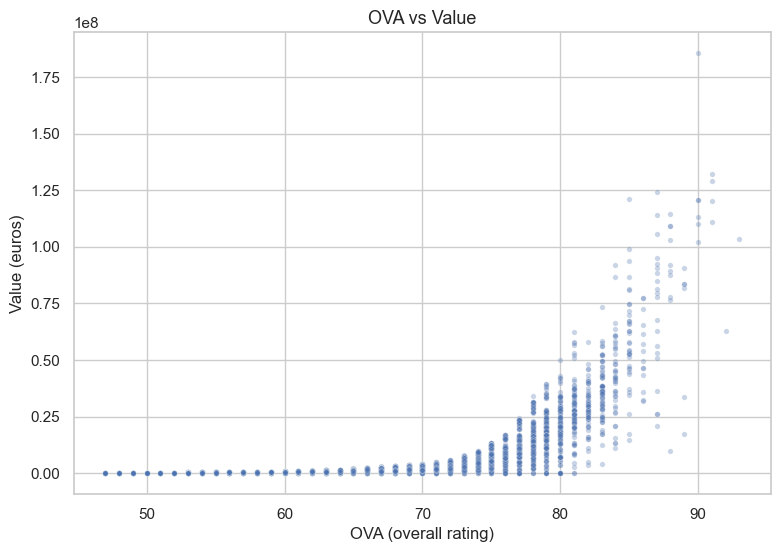

In [37]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=clean, x="↓OVA", y="Value", alpha=0.3, s=15)
plt.title("OVA vs Value")
plt.xlabel("OVA (overall rating)")
plt.ylabel("Value (euros)")
plt.show()

**Observation (C1):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Does Value rise steadily, or does it rise faster at high OVA?

### C2. Age against OVA

<Figure size 900x600 with 0 Axes>

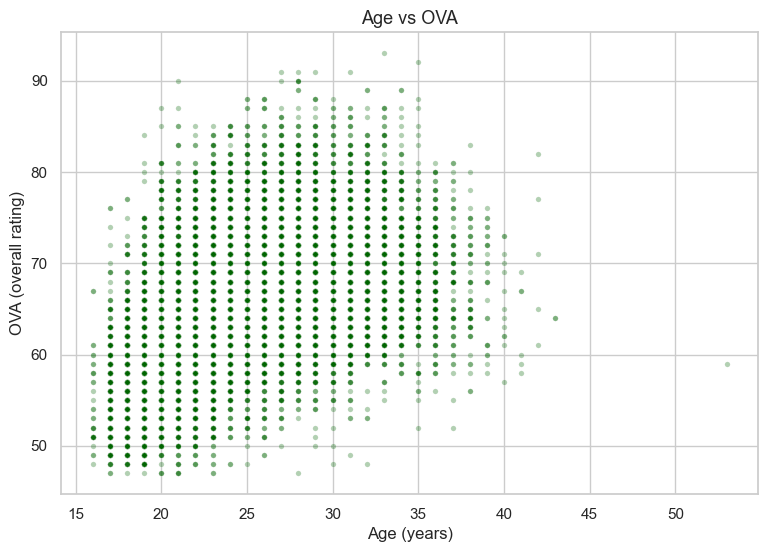

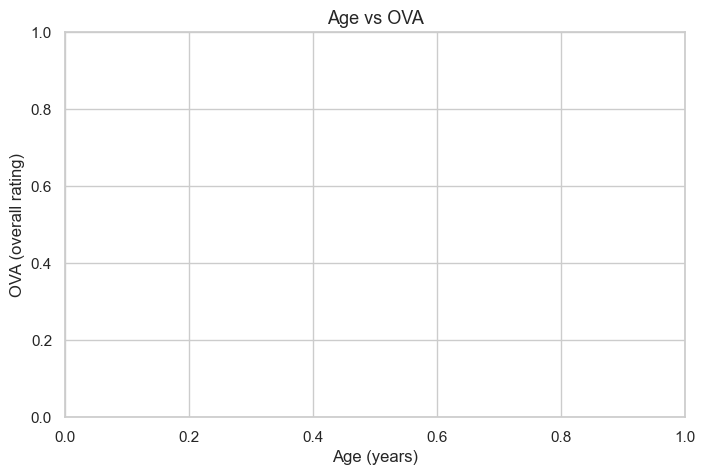

In [39]:
plt.figure(figsize=(9, 6))
plt.figure(figsize=(9, 6))
sns.scatterplot(data=clean, x="Age", y="↓OVA", alpha=0.3, s=15, color="darkgreen")
plt.title("Age vs OVA")
plt.xlabel("Age (years)")
plt.ylabel("OVA (overall rating)")
plt.show()
plt.title("Age vs OVA")
plt.xlabel("Age (years)")
plt.ylabel("OVA (overall rating)")
plt.show()

**Observation (C2):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: At what age do ratings seem highest?

### C3. OVA against POT with the line OVA = POT

<Figure size 800x800 with 0 Axes>

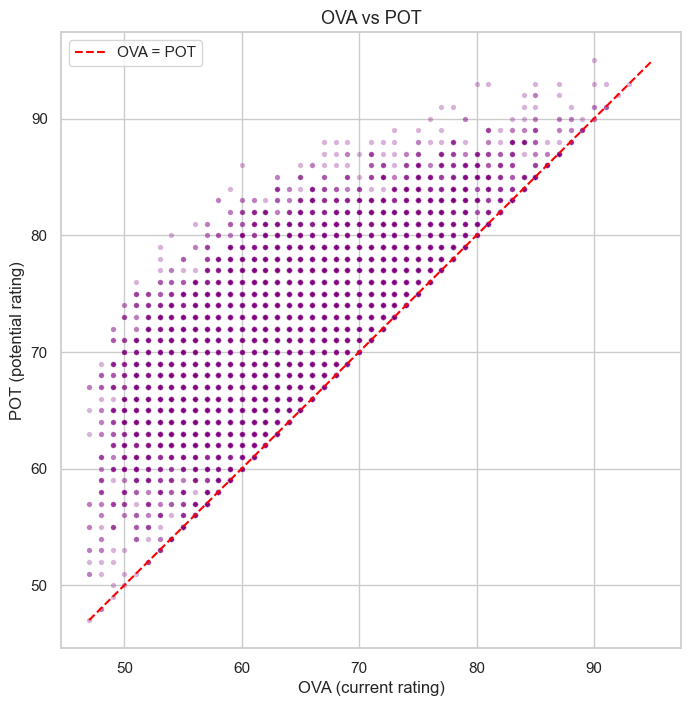

Players with POT at least 15 points above OVA: 1650
Their average age: 18.5 | overall average age: 25.2


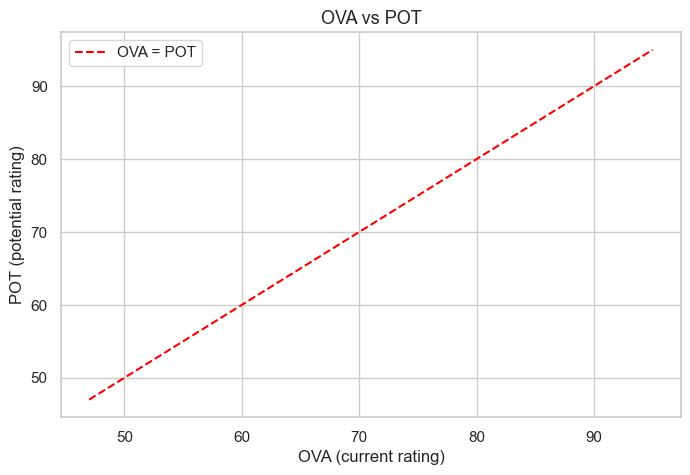

Players with POT at least 15 points above OVA: 1650
Their average age: 18.5 | overall average age: 25.2


In [43]:
plt.figure(figsize=(8, 8))
plt.figure(figsize=(8, 8))
sns.scatterplot(data=clean, x="↓OVA", y="POT", alpha=0.3, s=15, color="purple")
lims = [clean[["↓OVA", "POT"]].min().min(), clean[["↓OVA", "POT"]].max().max()]
plt.plot(lims, lims, color="red", linestyle="--", label="OVA = POT")
plt.title("OVA vs POT")
plt.xlabel("OVA (current rating)")
plt.ylabel("POT (potential rating)")
plt.legend()
plt.show()

# Players far above the line (potential much higher than current rating)
far = clean[(clean["POT"] - clean["↓OVA"]) >= 15]
print("Players with POT at least 15 points above OVA:", len(far))
print("Their average age:", round(far["Age"].mean(), 1), "| overall average age:", round(clean["Age"].mean(), 1))
lims = [clean[["↓OVA", "POT"]].min().min(), clean[["↓OVA", "POT"]].max().max()]
plt.plot(lims, lims, color="red", linestyle="--", label="OVA = POT")
plt.title("OVA vs POT")
plt.xlabel("OVA (current rating)")
plt.ylabel("POT (potential rating)")
plt.legend()
plt.show()

# Players far above the line (potential much higher than current rating)
far = clean[(clean["POT"] - clean["↓OVA"]) >= 15]
print("Players with POT at least 15 points above OVA:", len(far))
print("Their average age:", round(far["Age"].mean(), 1), "| overall average age:", round(clean["Age"].mean(), 1))

**Observation (C3):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Which players lie far above the line, and are they young or old?

### C4. OVA by Best Position (ordered by median)

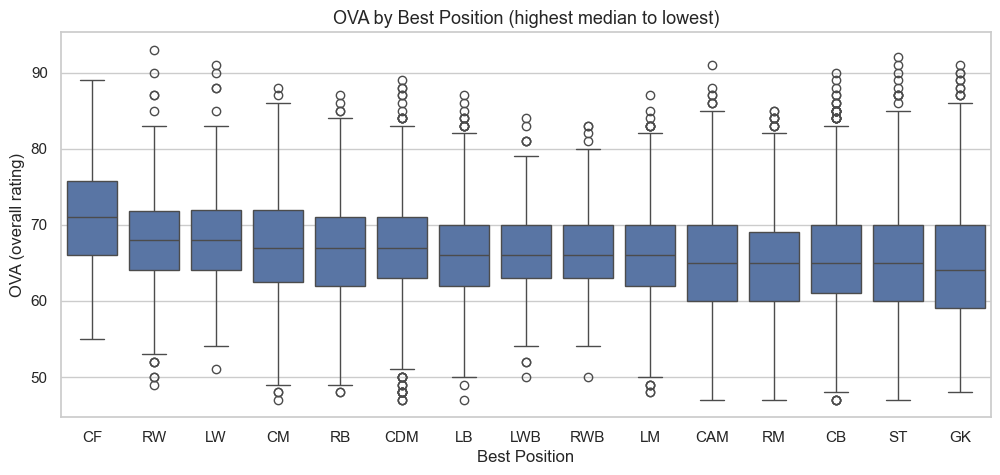

Top 3   : ['CF', 'RW', 'LW']
Bottom 3: ['CB', 'ST', 'GK']


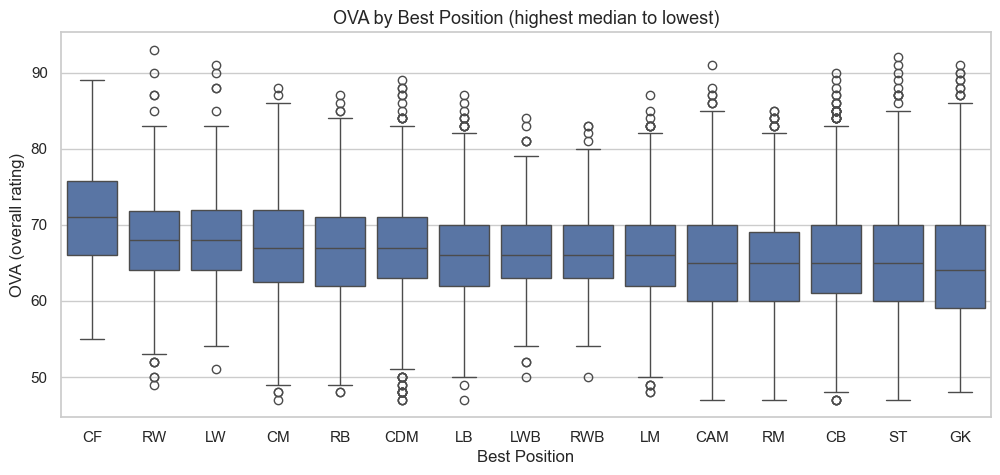

Top 3   : ['CF', 'RW', 'LW']
Bottom 3: ['CB', 'ST', 'GK']


In [46]:
order = (
    clean.groupby("Best Position")["↓OVA"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 5))
sns.boxplot(data=clean, x="Best Position", y="↓OVA", order=order)
plt.title("OVA by Best Position (highest median to lowest)")
plt.xlabel("Best Position")
plt.ylabel("OVA (overall rating)")
plt.show()

print("Top 3   :", list(order[:3]))
print("Bottom 3:", list(order[-3:]))
plt.figure(figsize=(12, 5))
sns.boxplot(data=clean, x="Best Position", y="↓OVA", order=order)
plt.title("OVA by Best Position (highest median to lowest)")
plt.xlabel("Best Position")
plt.ylabel("OVA (overall rating)")
plt.show()

print("Top 3   :", list(order[:3]))
print("Bottom 3:", list(order[-3:]))

**Observation (C4):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Name the top 3 and bottom 3 positions.

### C5. Average Value by Age

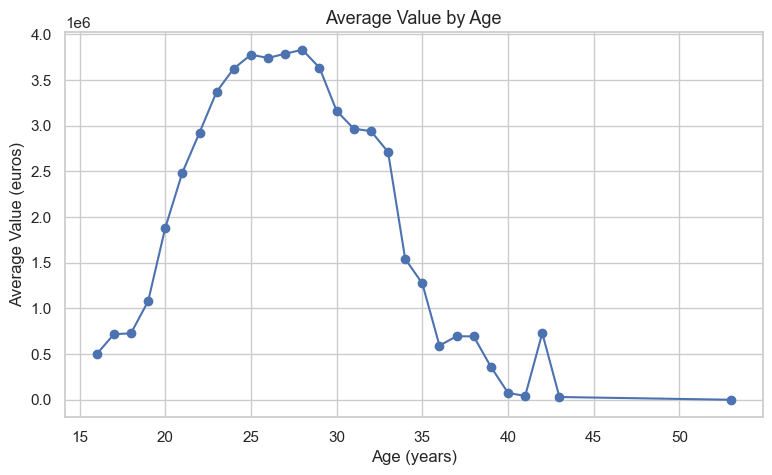

Age with the highest average Value: 28


In [47]:
avg_value_age = clean.groupby("Age")["Value"].mean()
plt.figure(figsize=(9, 5))
avg_value_age.plot(marker="o")
plt.title("Average Value by Age")
plt.xlabel("Age (years)")
plt.ylabel("Average Value (euros)")
plt.show()

print("Age with the highest average Value:", avg_value_age.idxmax())

**Observation (C5):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: At which age is the average Value highest?

### C6. Average OVA and POT by Age

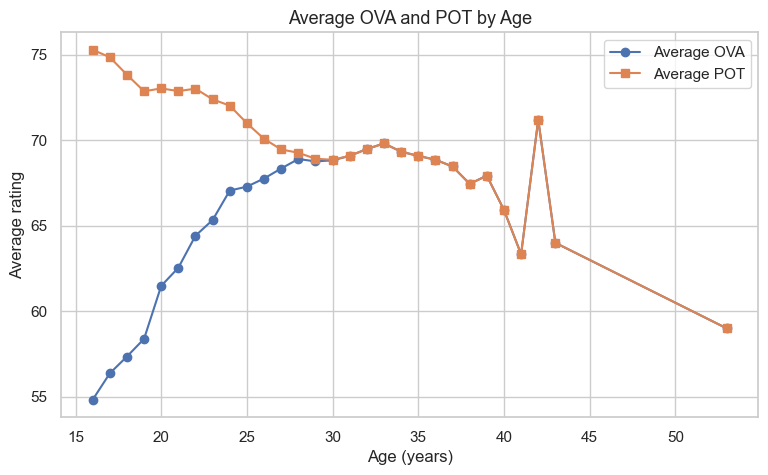

In [49]:
avg = clean.groupby("Age")[["↓OVA", "POT"]].mean().rename(columns={"↓OVA": "OVA"})
plt.figure(figsize=(9, 5))
plt.plot(avg.index, avg["OVA"], marker="o", label="Average OVA")
plt.plot(avg.index, avg["POT"], marker="s", label="Average POT")
plt.title("Average OVA and POT by Age")
plt.xlabel("Age (years)")
plt.ylabel("Average rating")
plt.legend()
plt.show()

**Observation (C6):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: At which ages are the two lines far apart, and at which ages do they meet?

### C7. Hexbin plot of OVA against Value

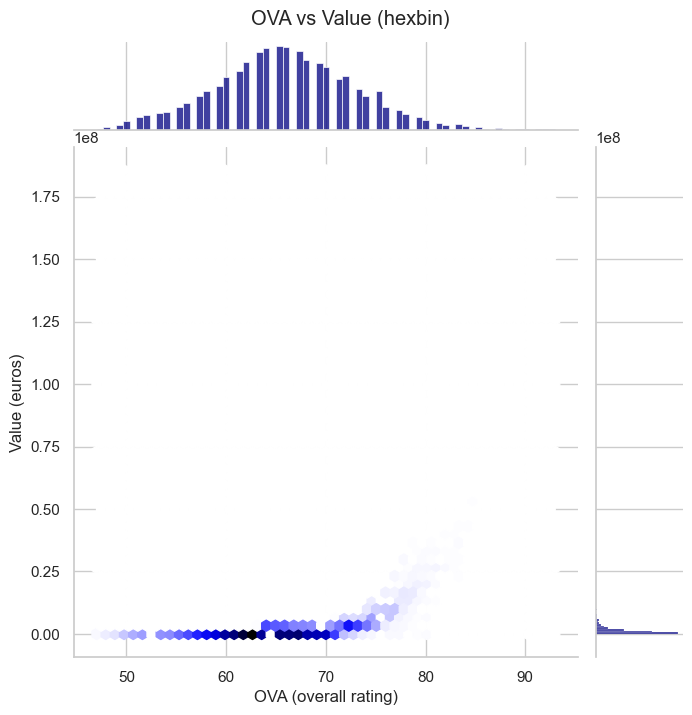

In [51]:
g = sns.jointplot(
    data=clean,
    x="↓OVA",   # exact column name in clean
    y="Value",
    kind="hex",
    height=7,
    color="navy"
)
g.set_axis_labels("OVA (overall rating)", "Value (euros)")
g.figure.suptitle("OVA vs Value (hexbin)", y=1.02)
plt.show()

**Observation (C7):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Where is the densest area?

### C8. Wage against Value (both axes on a log scale)

In [ ]:
# Filter only for drawing: log of 0 is undefined
pos = clean[(clean["Wage"] > 0) & (clean["Value"] > 0)]
print("Players left out of this plot (Wage or Value = 0):", len(clean) - len(pos))

plt.figure(figsize=(9, 6))
sns.scatterplot(data=pos, x="Wage", y="Value", alpha=0.3, s=15)
plt.xscale("log")
plt.yscale("log")
plt.title("Wage vs Value (log-log scale)")
plt.xlabel("Wage (euros per week, log scale)")
plt.ylabel("Value (euros, log scale)")
plt.show()

**Observation (C8):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Do the points follow a clear line?

### C9. Regression plot of Reactions against Value

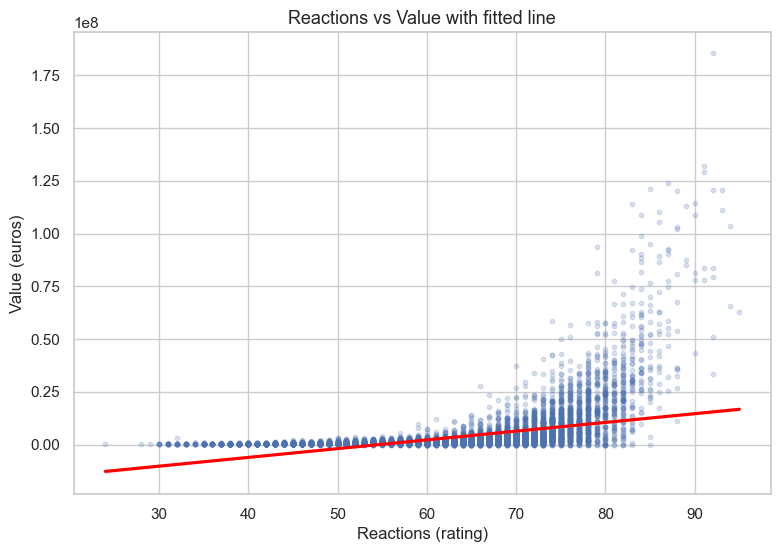

In [52]:
plt.figure(figsize=(9, 6))
sns.regplot(data=clean, x="Reactions", y="Value",
            scatter_kws={"alpha": 0.2, "s": 10}, line_kws={"color": "red"})
plt.title("Reactions vs Value with fitted line")
plt.xlabel("Reactions (rating)")
plt.ylabel("Value (euros)")
plt.show()

**Observation (C9):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Is the fitted line a good description of the points?

### C10. Average Value of each Best Position

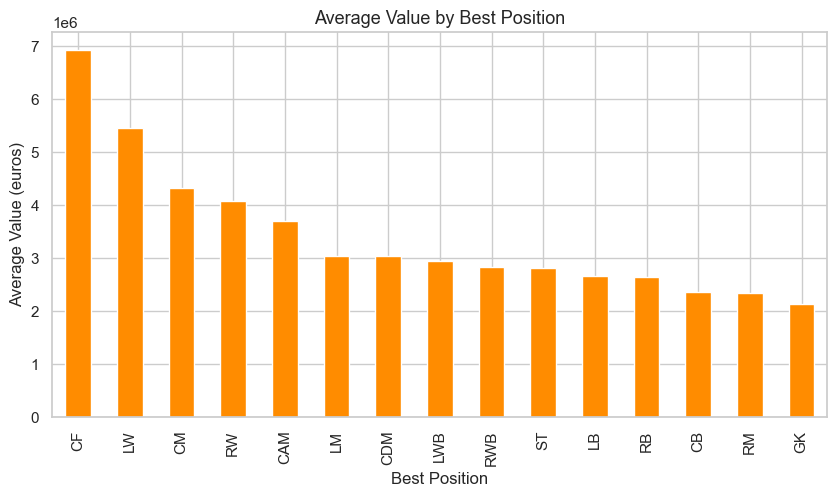

Best Position
CF    6.913910e+06
LW    5.443952e+06
CM    4.320606e+06
Name: Value, dtype: float64


In [53]:
pos_value = clean.groupby("Best Position")["Value"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
pos_value.plot.bar(color="darkorange")
plt.title("Average Value by Best Position")
plt.xlabel("Best Position")
plt.ylabel("Average Value (euros)")
plt.show()
print(pos_value.head(3))

**Observation (C10):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Which positions are worth the most on average?

### C11. Top 10 by Value and top 10 by Wage

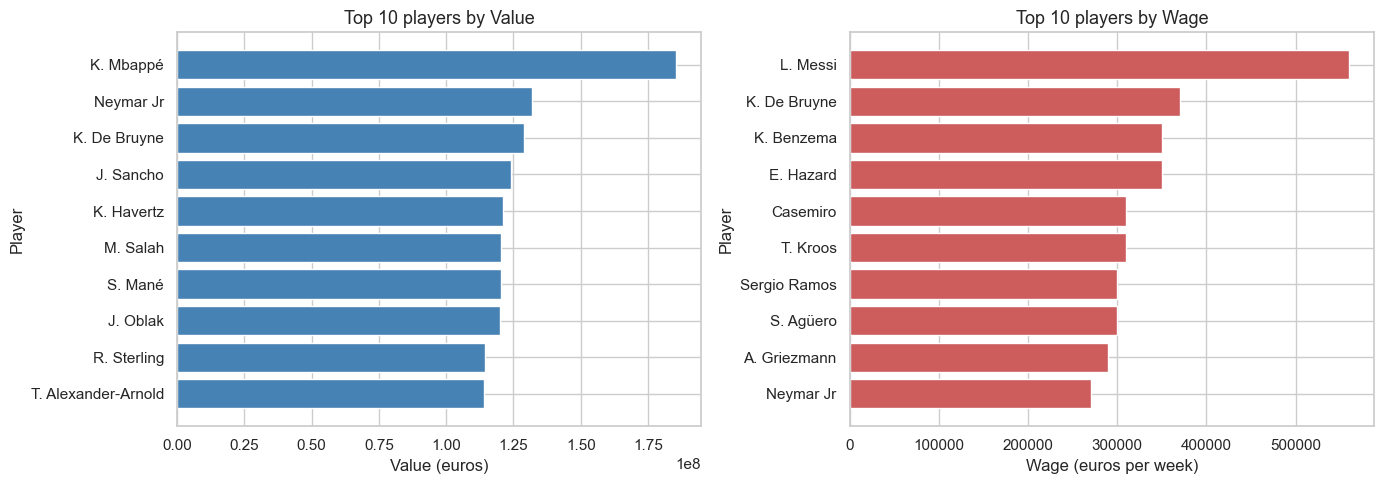

Players in both lists: ['K. De Bruyne', 'Neymar Jr']


In [54]:
top_val  = clean.nlargest(10, "Value")[["Name", "Value"]]
top_wage = clean.nlargest(10, "Wage")[["Name", "Wage"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top_val["Name"][::-1], top_val["Value"][::-1], color="steelblue")
axes[0].set_title("Top 10 players by Value")
axes[0].set_xlabel("Value (euros)")
axes[0].set_ylabel("Player")

axes[1].barh(top_wage["Name"][::-1], top_wage["Wage"][::-1], color="indianred")
axes[1].set_title("Top 10 players by Wage")
axes[1].set_xlabel("Wage (euros per week)")
axes[1].set_ylabel("Player")
plt.tight_layout()
plt.show()

print("Players in both lists:", sorted(set(top_val["Name"]) & set(top_wage["Name"])))

**Observation (C11):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Which players appear in both charts?

### C12 (Extra). Height against Weight, coloured by Preferred Foot

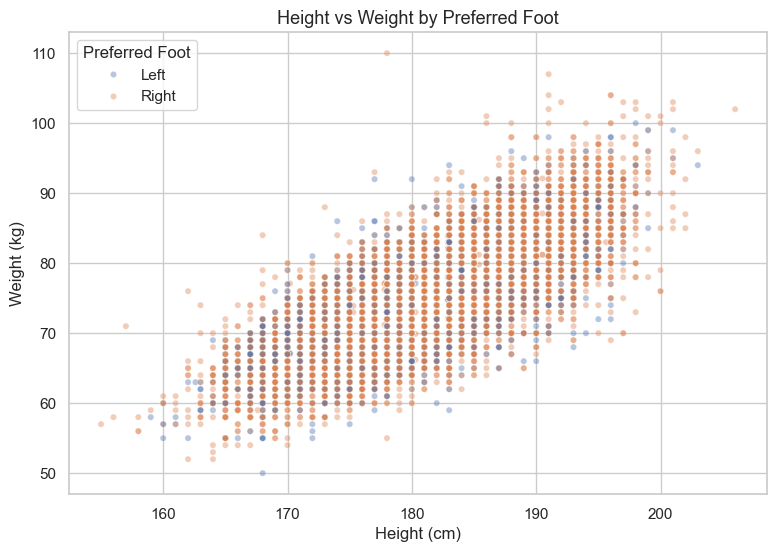

In [55]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=clean, x="Height", y="Weight", hue="Preferred Foot", alpha=0.4, s=20)
plt.title("Height vs Weight by Preferred Foot")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.show()

**Observation (C12 (Extra)):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Do the two colours separate?

### C13 (Extra). Free choice: one more plot you find interesting

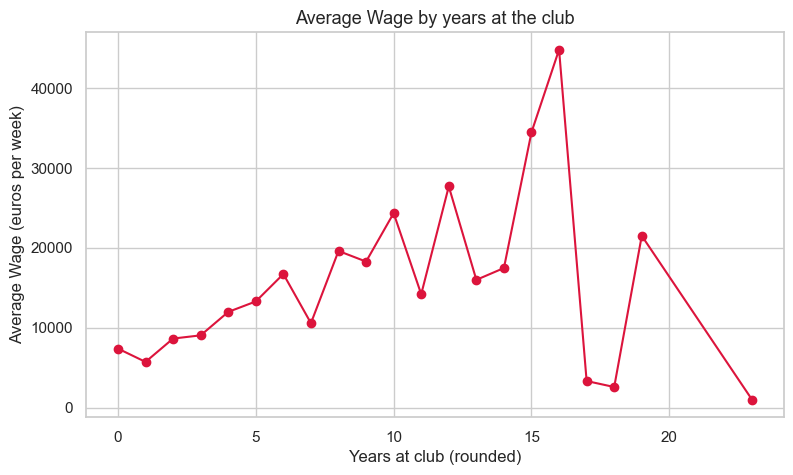

In [56]:
# Example choice (replace it with your own idea if you like):
# does a longer stay at the club go together with a higher average Wage?
yrs = clean.groupby(clean["Years_at_Club"].round())["Wage"].mean()
plt.figure(figsize=(9, 5))
yrs.plot(marker="o", color="crimson")
plt.title("Average Wage by years at the club")
plt.xlabel("Years at club (rounded)")
plt.ylabel("Average Wage (euros per week)")
plt.show()

**Observation (C13 (Extra)):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Why did you choose this plot, and what does it show?

## Part D: Many columns together (cleaned file)

### D1. Correlation heatmap: Value, OVA, POT, Age, Reactions, Wage, Hits

<Figure size 800x600 with 0 Axes>

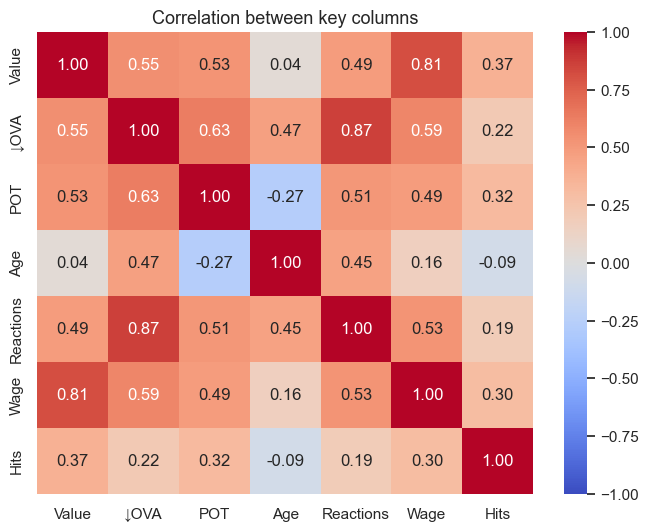

Wage         0.814870
↓OVA         0.552893
POT          0.528200
Reactions    0.489513
Hits         0.374601
Age          0.040994
Name: Value, dtype: float64


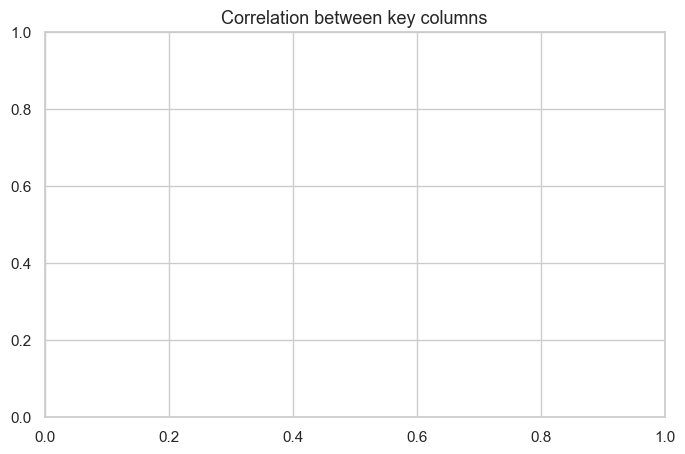

Wage         0.814870
↓OVA         0.552893
POT          0.528200
Reactions    0.489513
Hits         0.374601
Age          0.040994
Name: Value, dtype: float64


In [58]:
d1 = ["Value", "OVA", "POT", "Age", "Reactions", "Wage", "Hits"]
plt.figure(figsize=(8, 6))
d1 = ["Value", "↓OVA", "POT", "Age", "Reactions", "Wage", "Hits"]
plt.figure(figsize=(8, 6))
sns.heatmap(
    clean[d1].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Correlation between key columns")
plt.show()

print(clean[d1].corr()["Value"].drop("Value").sort_values(ascending=False))
plt.title("Correlation between key columns")
plt.show()

print(clean[d1].corr()["Value"].drop("Value").sort_values(ascending=False))

**Observation (D1):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Which column has the strongest relation with Value? Which has the weakest?

### D2. Correlation heatmap: PAC, SHO, PAS, DRI, DEF, PHY, Height, Weight

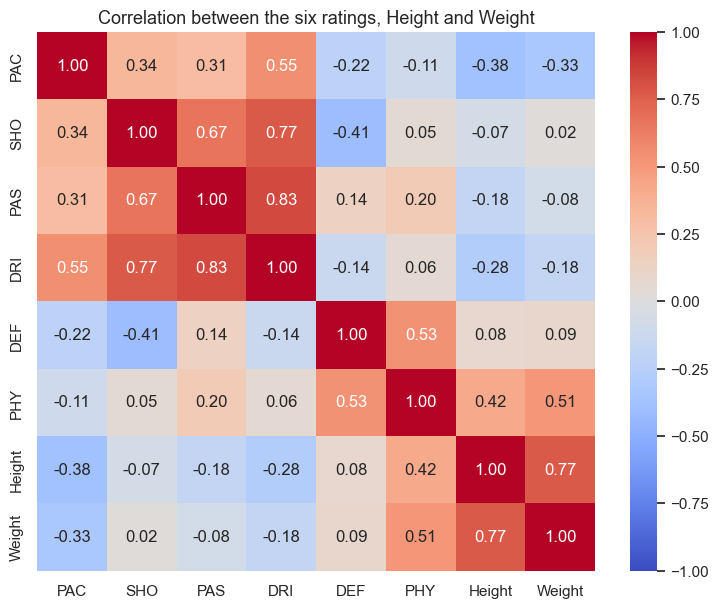

In [59]:
d2 = ["PAC", "SHO", "PAS", "DRI", "DEF", "PHY", "Height", "Weight"]
plt.figure(figsize=(9, 7))
sns.heatmap(clean[d2].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between the six ratings, Height and Weight")
plt.show()

**Observation (D2):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Find one strongly related pair (close to +1 or -1) and one negatively related pair.

### D3. Pairplot of Value, OVA, Age and Wage (sample of 500 players)

In [60]:
sample500 = clean[["Value", "↓OVA", "Age", "Wage"]].sample(500, random_state=42)
g = sns.pairplot(sample500, corner=False)
g.figure.suptitle("Pairplot of Value, OVA, Age and Wage (500 random players)", y=1.02)
plt.show()

KeyError: "['OVA'] not in index"

**Observation (D3):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Describe one pattern you see.

### D4. The 15 columns most strongly related to Value

In [ ]:
corr_val = clean.corr(numeric_only=True)["Value"].drop("Value")
top15 = corr_val.reindex(corr_val.abs().sort_values(ascending=False).index).head(15)

plt.figure(figsize=(9, 6))
top15[::-1].plot.barh(color="teal")
plt.title("15 columns most strongly related to Value")
plt.xlabel("Correlation with Value")
plt.ylabel("Column")
plt.show()
print(top15)

**Observation (D4):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Which skill columns are at the top?

### D5. Average PAC, SHO, PAS, DRI, DEF, PHY per Best Position

In [ ]:
six = ["PAC", "SHO", "PAS", "DRI", "DEF", "PHY"]
pos_means = clean.groupby("Best Position")[six].mean()
plt.figure(figsize=(9, 8))
sns.heatmap(pos_means, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average ratings by Best Position")
plt.xlabel("Rating")
plt.ylabel("Best Position")
plt.show()

**Observation (D5):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Which position is strongest in which rating?

### D6. Correlation heatmap of attacking and skill columns

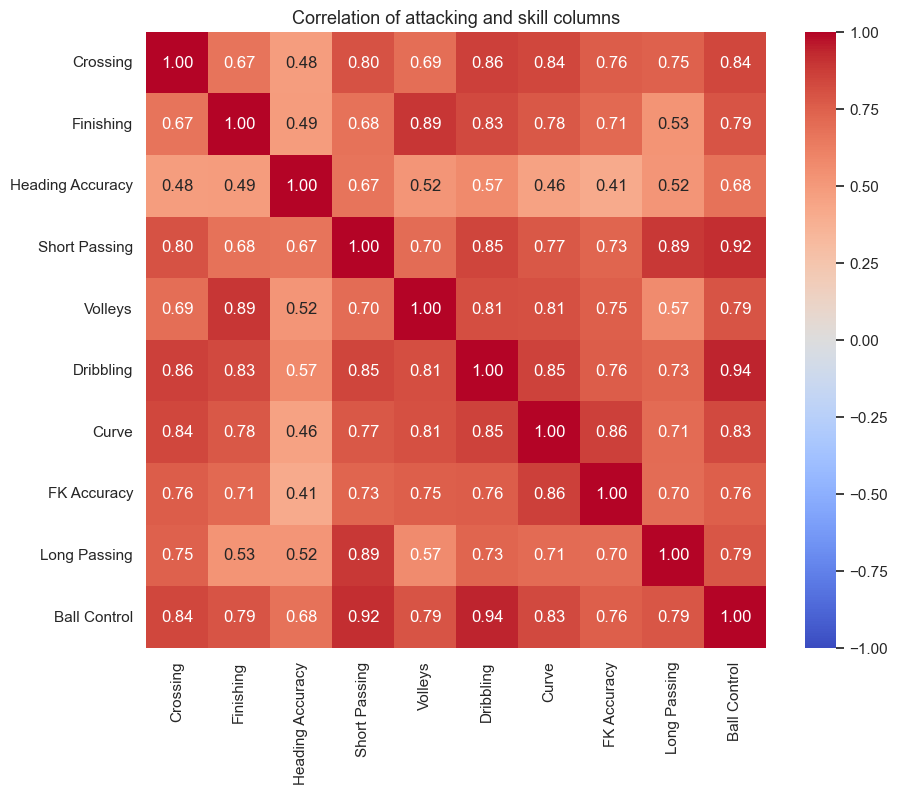

In [61]:
d6 = ["Crossing", "Finishing", "Heading Accuracy", "Short Passing", "Volleys",
      "Dribbling", "Curve", "FK Accuracy", "Long Passing", "Ball Control"]
plt.figure(figsize=(10, 8))
sns.heatmap(clean[d6].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of attacking and skill columns")
plt.show()

**Observation (D6):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Which group of columns moves together?

### D7 (Extra). Goalkeeping columns together with Value

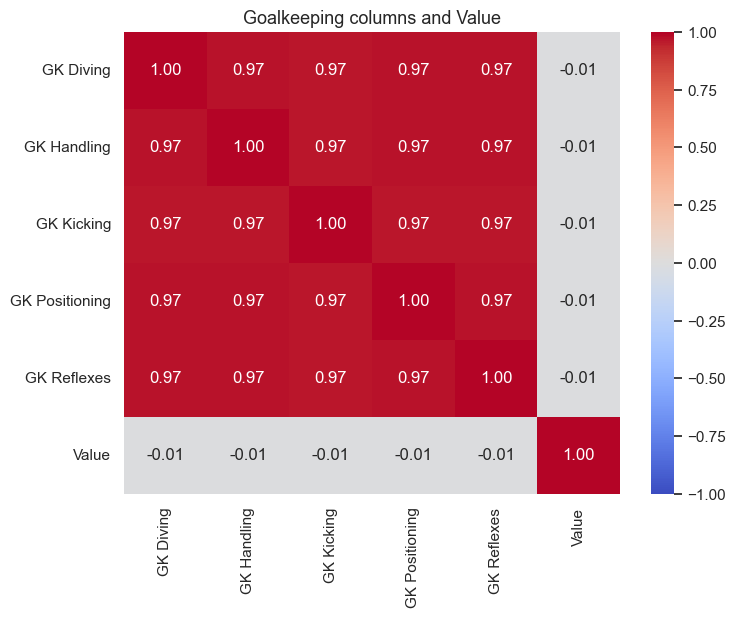

In [62]:
d7 = ["GK Diving", "GK Handling", "GK Kicking", "GK Positioning", "GK Reflexes", "Value"]
plt.figure(figsize=(8, 6))
sns.heatmap(clean[d7].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Goalkeeping columns and Value")
plt.show()

**Observation (D7 (Extra)):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Why do these behave differently from the outfield columns?

## Part E: Categories (cleaned file)

### E1. Number of different values

In [63]:
cat_cols = ["Nationality", "Club", "Preferred Foot", "A/W", "D/W"]
print(clean[cat_cols].nunique())

Nationality       164
Club              682
Preferred Foot      2
A/W                 3
D/W                 3
dtype: int64


**Observation (E1):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Which have only a few values and which have many?

### E2. Top 10 nationalities by number of players

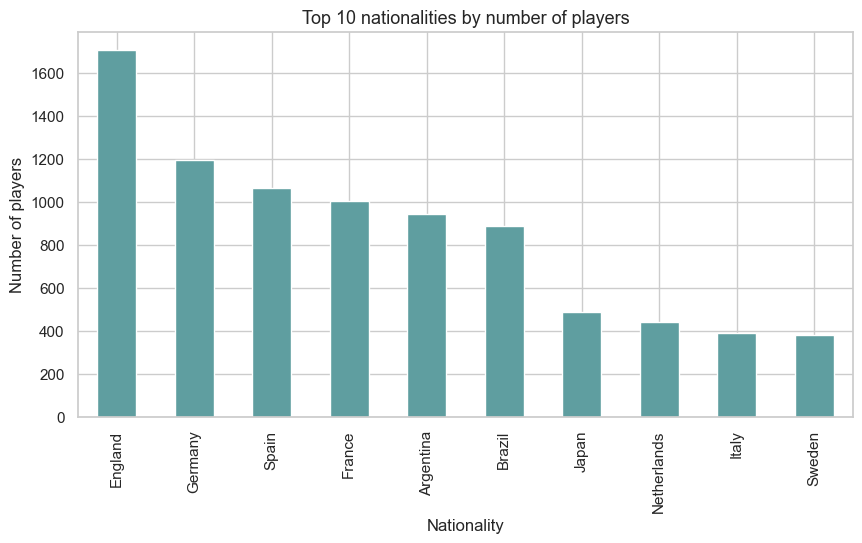

In [64]:
plt.figure(figsize=(10, 5))
clean["Nationality"].value_counts().head(10).plot.bar(color="cadetblue")
plt.title("Top 10 nationalities by number of players")
plt.xlabel("Nationality")
plt.ylabel("Number of players")
plt.show()

**Observation (E2):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Which nationalities lead, and how big is the gap to the rest?

### E3. Top 10 clubs by average Value (clubs with at least 15 players)

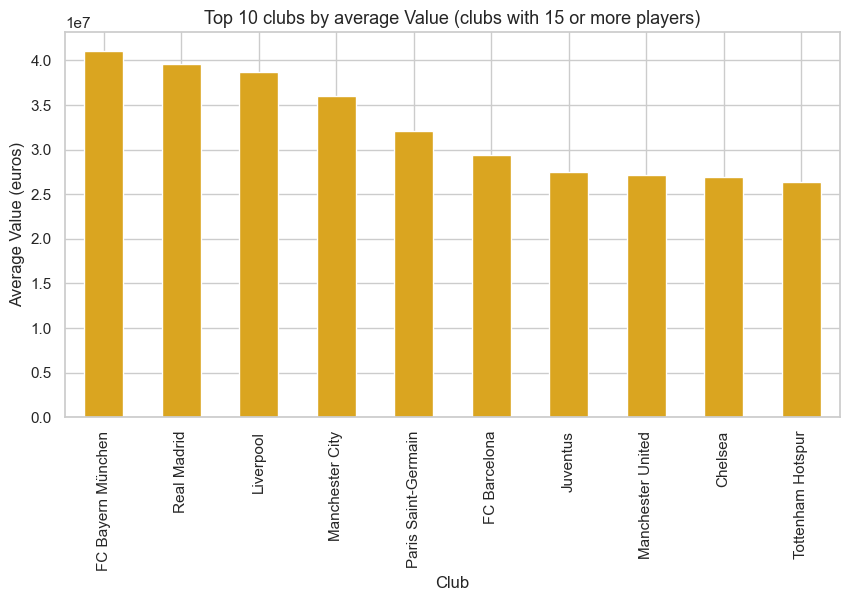

In [65]:
g = clean.groupby("Club")["Value"].agg(["mean", "count"])
top_clubs = g[g["count"] >= 15].sort_values("mean", ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_clubs["mean"].plot.bar(color="goldenrod")
plt.title("Top 10 clubs by average Value (clubs with 15 or more players)")
plt.xlabel("Club")
plt.ylabel("Average Value (euros)")
plt.show()

**Observation (E3):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Which clubs have the highest average Value?

### E4. Preferred Foot: count plot and boxplot of Value

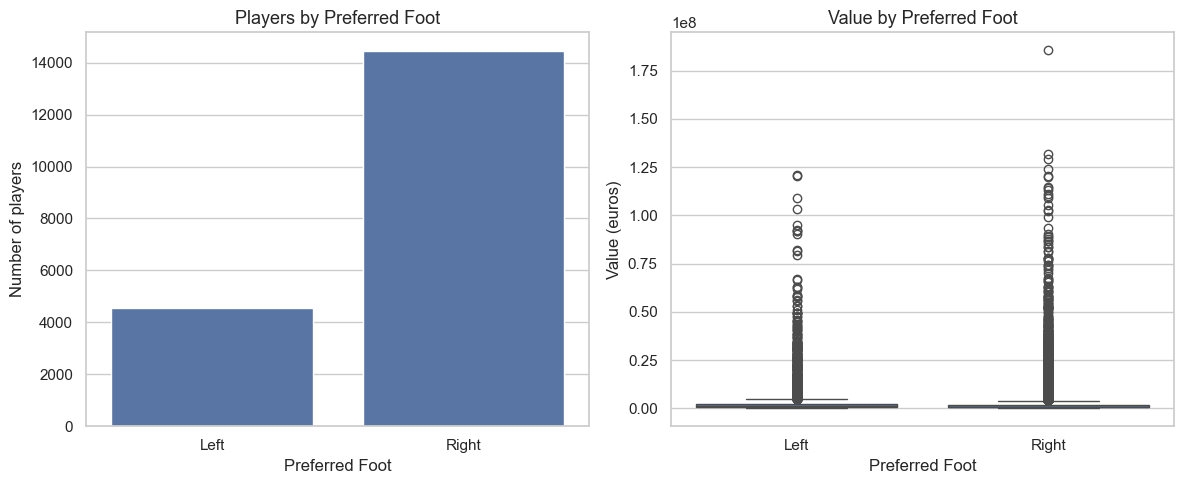

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=clean, x="Preferred Foot", ax=axes[0])
axes[0].set_title("Players by Preferred Foot")
axes[0].set_xlabel("Preferred Foot")
axes[0].set_ylabel("Number of players")

sns.boxplot(data=clean, x="Preferred Foot", y="Value", ax=axes[1])
axes[1].set_title("Value by Preferred Foot")
axes[1].set_xlabel("Preferred Foot")
axes[1].set_ylabel("Value (euros)")
plt.tight_layout()
plt.show()

**Observation (E4):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Does the foot make a visible difference to Value?

### E5. Value by W/F and by SM (star ratings 1 to 5)

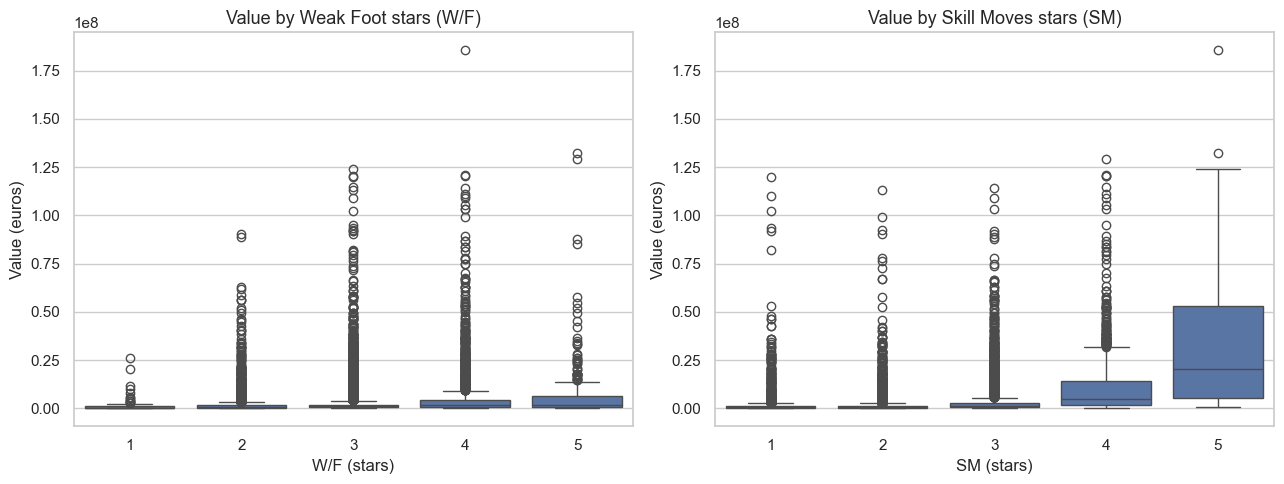

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=clean, x="W/F", y="Value", ax=axes[0])
axes[0].set_title("Value by Weak Foot stars (W/F)")
axes[0].set_xlabel("W/F (stars)")
axes[0].set_ylabel("Value (euros)")

sns.boxplot(data=clean, x="SM", y="Value", ax=axes[1])
axes[1].set_title("Value by Skill Moves stars (SM)")
axes[1].set_xlabel("SM (stars)")
axes[1].set_ylabel("Value (euros)")
plt.tight_layout()
plt.show()

**Observation (E5):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Does Value rise with the number of stars?

### E6. Count plots of A/W and D/W

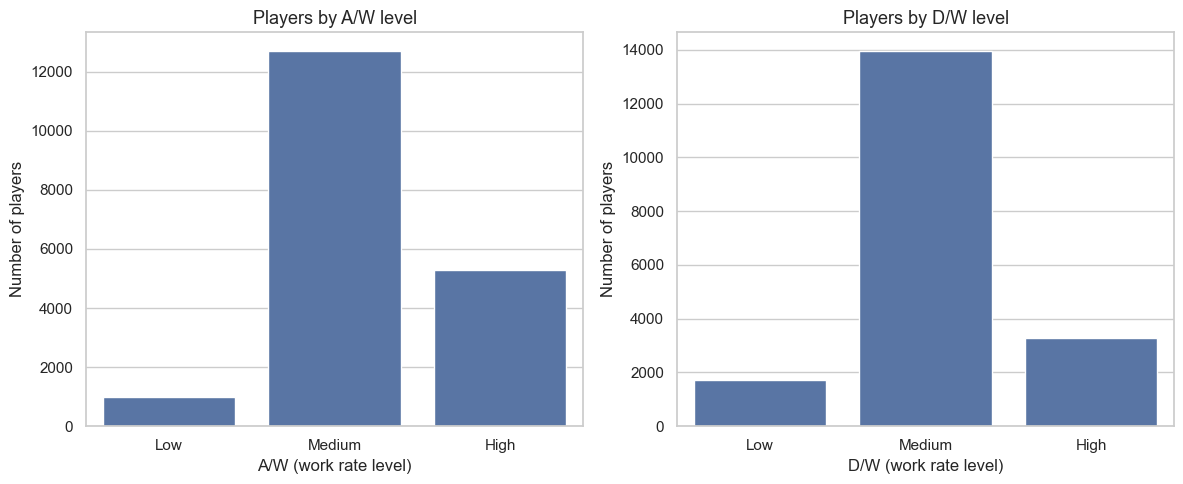

In [68]:
levels = ["Low", "Medium", "High"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ["A/W", "D/W"]):
    order = [l for l in levels if l in clean[col].unique()]
    sns.countplot(data=clean, x=col, order=order, ax=ax)
    ax.set_title(f"Players by {col} level")
    ax.set_xlabel(f"{col} (work rate level)")
    ax.set_ylabel("Number of players")
plt.tight_layout()
plt.show()

**Observation (E6):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Which level is most common in each?

### E7 (Extra). 6 most common Best Positions, split by Preferred Foot

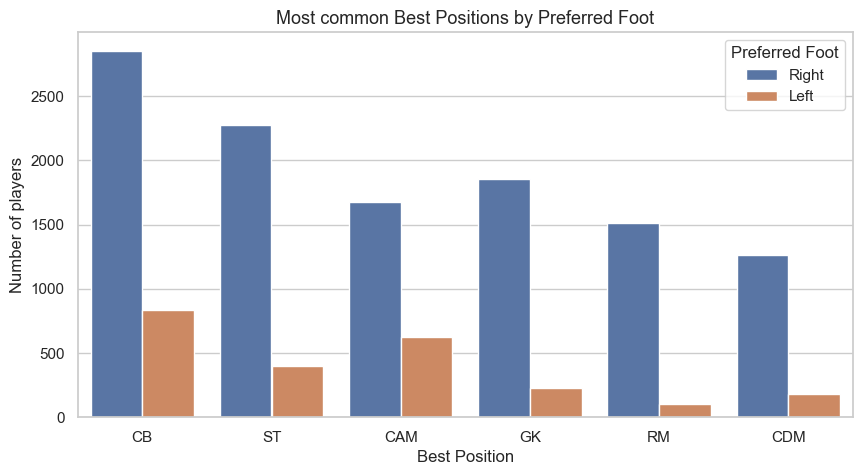

In [69]:
top6 = clean["Best Position"].value_counts().head(6).index
plt.figure(figsize=(10, 5))
sns.countplot(data=clean[clean["Best Position"].isin(top6)],
              x="Best Position", hue="Preferred Foot", order=top6)
plt.title("Most common Best Positions by Preferred Foot")
plt.xlabel("Best Position")
plt.ylabel("Number of players")
plt.show()

**Observation (E7 (Extra)):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Is any position dominated by left-footed players?

## Part F: Raw versus cleaned (compare both files)

### F1. Missing values of both files for the same columns

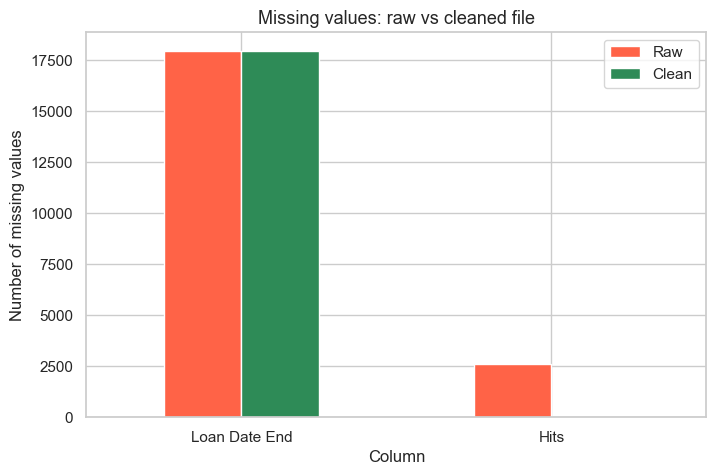

,Raw,Clean
Loan Date End,17966,17966
Hits,2595,0


In [70]:
# Series copies only (the raw dataframe itself is not changed)
miss_raw = raw.isnull().sum()
miss_raw.index = miss_raw.index.str.replace("↓", "", regex=False).str.strip()
miss_clean = clean.isnull().sum()

common = miss_raw.index.intersection(miss_clean.index)
cmp_df = pd.DataFrame({"Raw": miss_raw[common], "Clean": miss_clean[common]})
cmp_df = cmp_df[(cmp_df["Raw"] > 0) | (cmp_df["Clean"] > 0)]

cmp_df.plot.bar(figsize=(8, 5), color=["tomato", "seagreen"])
plt.title("Missing values: raw vs cleaned file")
plt.xlabel("Column")
plt.ylabel("Number of missing values")
plt.xticks(rotation=0)
plt.show()
display(cmp_df)

**Observation (F1):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Which column changed, and why?

### F2. Histogram of Age from both files

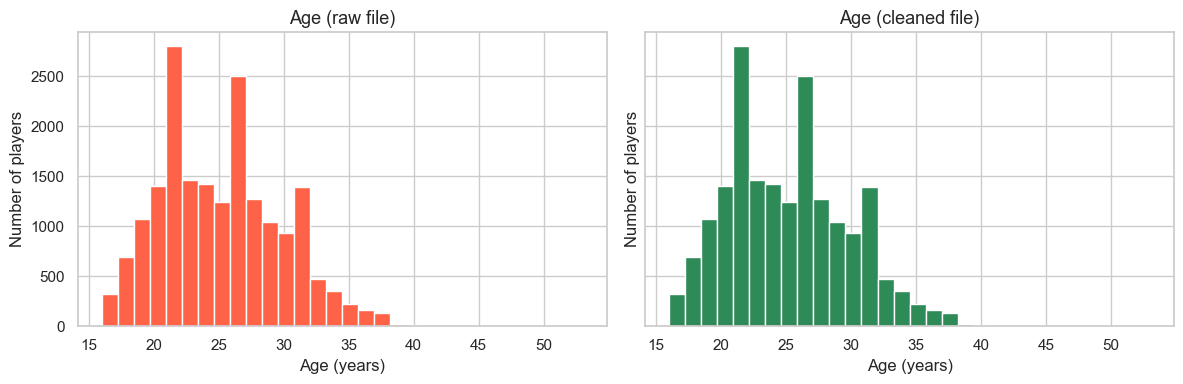

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(raw["Age"], bins=30, color="tomato", edgecolor="white")
axes[0].set_title("Age (raw file)")
axes[1].hist(clean["Age"], bins=30, color="seagreen", edgecolor="white")
axes[1].set_title("Age (cleaned file)")
for ax in axes:
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Number of players")
plt.tight_layout()
plt.show()

**Observation (F2):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Are they the same? Why or why not?

### F3. Histogram of OVA from both files (↓OVA for the raw file)

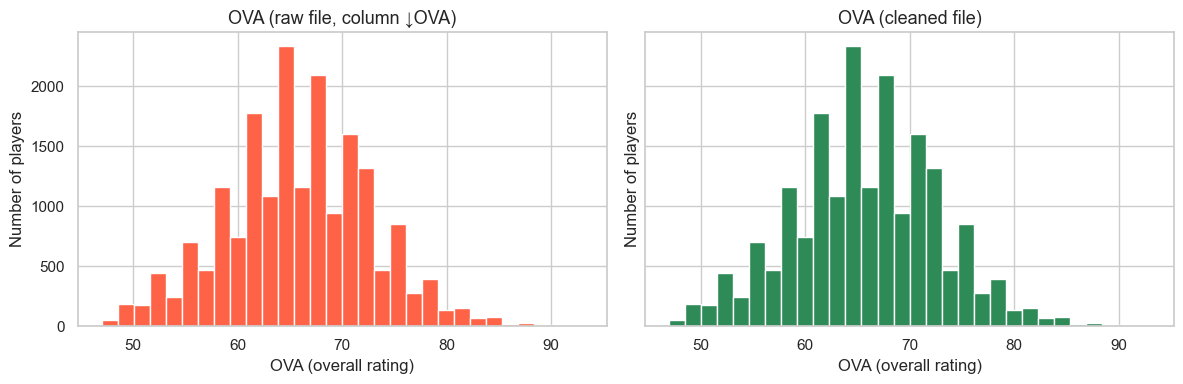

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(raw[RAW_OVA], bins=30, color="tomato", edgecolor="white")
axes[0].set_title(f"OVA (raw file, column {RAW_OVA})")
axes[1].hist(clean["↓OVA"], bins=30, color="seagreen", edgecolor="white")
axes[1].set_title("OVA (cleaned file)")
for ax in axes:
    ax.set_xlabel("OVA (overall rating)")
    ax.set_ylabel("Number of players")
plt.tight_layout()
plt.show()

**Observation (F3):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: Do they match?

### F4. Raw Height formats

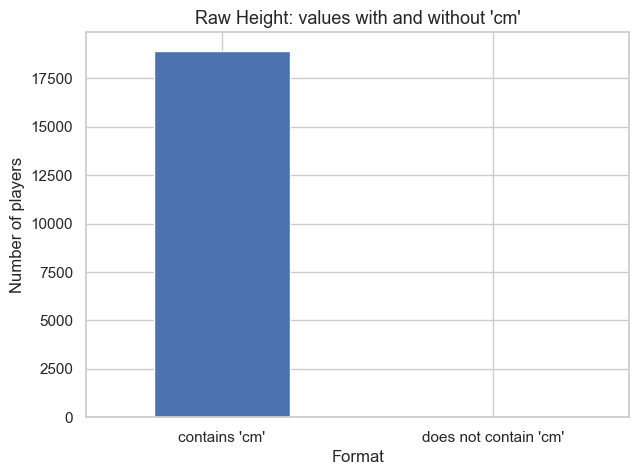

Examples of the second group:
['6\'2"', '6\'3"', '6\'5"', '5\'11"', '6\'4"']


In [74]:
has_cm = raw["Height"].str.contains("cm").map({True: "contains 'cm'", False: "does not contain 'cm'"})
counts = has_cm.value_counts()
plt.figure(figsize=(7, 5))
counts.plot.bar(color=["#4c72b0", "#dd8452"])
plt.title("Raw Height: values with and without 'cm'")
plt.xlabel("Format")
plt.ylabel("Number of players")
plt.xticks(rotation=0)
plt.show()

print("Examples of the second group:")
print(raw.loc[~raw["Height"].str.contains("cm"), "Height"].head(5).tolist())

**Observation (F4):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: What does the second group look like?

### F5. Raw Weight formats

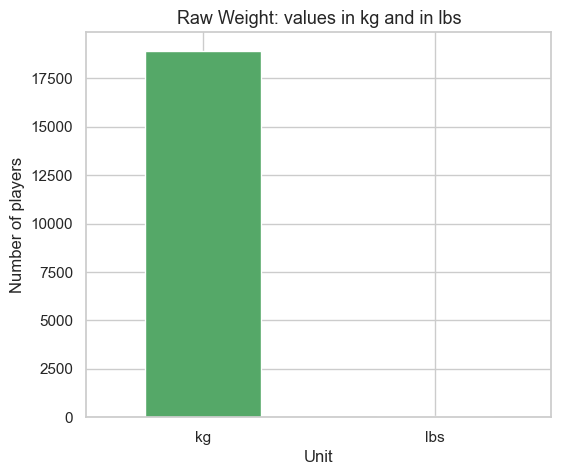

kg     18939
lbs       40
dtype: int64


In [75]:
w_counts = pd.Series({
    "kg":  raw["Weight"].str.contains("kg").sum(),
    "lbs": raw["Weight"].str.contains("lbs").sum(),
})
plt.figure(figsize=(6, 5))
w_counts.plot.bar(color=["#55a868", "#c44e52"])
plt.title("Raw Weight: values in kg and in lbs")
plt.xlabel("Unit")
plt.ylabel("Number of players")
plt.xticks(rotation=0)
plt.show()
print(w_counts)

**Observation (F5):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: What problem would the mix of kg and lbs cause for a model?

### F6. Raw W/F against cleaned W/F

C:\Users\Abubakar Sadiq\AppData\Local\Temp\ipykernel_4864\383747983.py:9: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Abubakar Sadiq\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


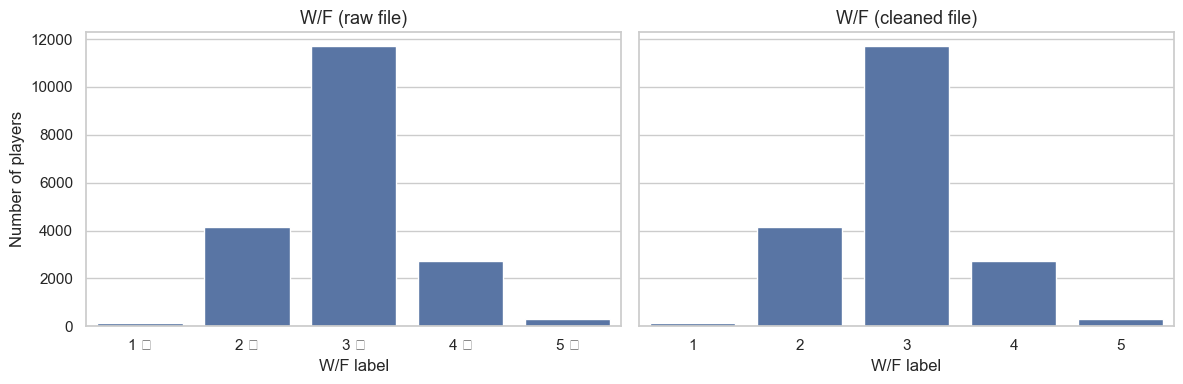

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.countplot(data=raw, x="W/F", order=sorted(raw["W/F"].dropna().unique()), ax=axes[0])
axes[0].set_title("W/F (raw file)")
sns.countplot(data=clean, x="W/F", order=sorted(clean["W/F"].unique()), ax=axes[1])
axes[1].set_title("W/F (cleaned file)")
for ax in axes:
    ax.set_xlabel("W/F label")
    ax.set_ylabel("Number of players")
plt.tight_layout()
plt.show()

**Observation (F6):** ✏️ *Write your own 1 to 2 sentences here.*

> Guiding question: How do the labels differ?

### F7. Changes between the raw and cleaned files
*(Pre-filled from the cleaning lab. Check each row against your own outputs and add more if you found any.)*

| # | Column | Raw file | Cleaned file |
|---|---|---|---|
| 1 | Value, Wage, Release Clause | text such as `€67.5M`, `€220K` | plain numbers such as 67500000, 220000 |
| 2 | Height | text, cm and feet/inches mixed | number in cm, 1 decimal |
| 3 | Weight | text, kg and lbs mixed | number in kg, 1 decimal |
| 4 | W/F, SM, IR | text with a star, such as `4 ★` | plain numbers 1 to 5 |
| 5 | Hits | text with K (`1.6K`) and missing cells | numbers, K converted, missing filled with the median |
| 6 | Joined | text such as `Jul 1, 2004` | real date (saved as text in the CSV) |
| 7 | Club (and other text) | line breaks and extra spaces | removed |
| 8 | Column name | `↓OVA` | `OVA` |
| 9 | New columns | not present | `Years_at_Club`, `Wage_Outlier` |

### F8. Which columns could not be plotted before cleaning, and why does cleaning matter?
✏️ *Write 3 to 4 lines here in your own words.*

## Final Summary (5 to 8 lines)
✏️ *Write your answers here in your own words, and copy them to paper.*

1. **The three most important things I learned about Value:**
2. **The columns most strongly related to Value:**
3. **One pair of columns that repeat the same information:**
4. **The biggest difference between the raw and cleaned files:**
5. **One question I would like to answer in the next lab:**